# 🏥 BiomedCLIP + Qwen2.5 — Medical VQA (SLAKE)

**Architecture (Hướng 3):**
```
Image ──► BiomedCLIP Vision Encoder (frozen/partial) ──► image_feat (512d)
                                                              │
                                                    MLP Projector (512 → 896d)
                                                              │
Question ──► Qwen2.5-0.5B Tokenizer ──► [visual_token, text_tokens] ──► Qwen2.5-0.5B ──► Answer
```

**Tại sao setup này?**
- BiomedCLIP được pretrain trên 15M+ PubMed image-text pairs → image encoder hiểu medical domain tốt
- Qwen2.5-0.5B (~500M params) nhỏ gọn, chạy được trên T4 16GB
- Projector (MLP 2 lớp) bridge 2 modalities → model học được cách fuse visual + text
- Train: BiomedCLIP freeze + Projector train + Qwen2.5 LoRA → balance VRAM và hiệu quả

Notebook hỗ trợ:
- ✅ Fine-tune BiomedCLIP + Qwen2.5-0.5B (LoRA) trên SLAKE-vqa-english
- ✅ Lưu checkpoint sau mỗi epoch
- ✅ Resume training từ checkpoint bất kỳ
- ✅ Full evaluate: EM, Token F1, BLEU, ROUGE-L, Cosine Sim
- ✅ Inference đơn lẻ

```
Luồng:
  [Lần đầu]  → Cell A → Train → lưu checkpoint
  [Resume]   → Cell B → Train tiếp
  [Evaluate] → Phần 7 (chạy độc lập)
```

**VRAM estimate:** ~9–11 GB → chạy được trên T4 Kaggle (16GB) / Colab free (15GB)

## 🔑 Token (Kaggle Secrets)

In [1]:
# Nếu dùng Kaggle — lấy HF token từ Secrets
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("NLP")   # tên secret bạn đặt
    print('✅ Token loaded từ Kaggle Secrets')
except Exception:
    # Nếu dùng Colab
    HF_TOKEN = 'hf_...'   # <- Thay token của bạn (vào https://huggingface.co/settings/tokens)
    print('⚠️  Dùng HF_TOKEN hardcode — nhớ xóa trước khi share notebook')

✅ Token loaded từ Kaggle Secrets


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

## 📦 Phần 1: Cài đặt

In [3]:
!pip install -q transformers datasets accelerate pillow
!pip install -q bitsandbytes peft
!pip install -q open_clip_torch huggingface_hub
!pip install -q rouge-score sentence-transformers nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
✅ Done!


In [4]:
import torch, os, json, shutil, re
from pathlib import Path
from collections import Counter

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM    : {vram:.1f} GB')
    USE_4BIT = vram < 20
else:
    USE_4BIT = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'4-bit   : {USE_4BIT}')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
4-bit   : True


## ⚙️ Phần 2: Config — chỉnh tại đây

In [5]:
# ============================================================
#   CONFIG
# ============================================================
DEVICE = 'cuda:0'

# ---- BiomedCLIP ----
# microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
# Tải qua open_clip_torch; weights tự động download từ HuggingFace
BIOMEDCLIP_MODEL = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
IMAGE_SIZE       = 224       # BiomedCLIP mặc định 224
IMAGE_FEAT_DIM   = 512       # output dim của BiomedCLIP vision encoder

# Freeze strategy:
# 'full'   → freeze toàn bộ BiomedCLIP (nhẹ nhất, VRAM ~9GB)
# 'last2'  → freeze tất cả trừ 2 layer cuối (cân bằng)
# 'none'   → train toàn bộ (nặng, không khuyến nghị với T4)
BIOMEDCLIP_FREEZE = 'full'

# ---- LLM Decoder ----
# 'Qwen/Qwen2.5-0.5B-Instruct'  → nhẹ nhất, ~1GB, hidden=896
# 'Qwen/Qwen2.5-1.5B-Instruct'  → tốt hơn, ~3GB, hidden=1536 (cần VRAM > 14GB)
LLM_MODEL   = 'Qwen/Qwen2.5-0.5B-Instruct'
LLM_HIDDEN  = 896    # phải khớp với model: 0.5B=896, 1.5B=1536

# ---- LoRA trên LLM ----
USE_LORA     = True
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'v_proj', 'k_proj', 'o_proj']

# ---- MLP Projector ----
# Bridge BiomedCLIP (512d) → LLM hidden (896d)
# Dùng 2-layer MLP với GELU: 512 → 1024 → 896
PROJECTOR_HIDDEN = 1024

# ---- Checkpoint ----
CHECKPOINT_DIR  = '/kaggle/working/checkpoints'
EXPERIMENT_NAME = 'biomedclip_qwen_slake'
SAVE_EVERY_N    = 1     # lưu sau mỗi N epoch
KEEP_LAST_N     = 3     # giữ N checkpoint gần nhất

# ---- Dataset ----
DATASET_NAME = 'mdwiratathya/SLAKE-vqa-english'
TRAIN_SPLIT  = 'train'
TEST_SPLIT   = 'test'
Q_COL        = 'question'
A_COL        = 'answer'

# ---- Hyperparameters ----
BATCH_SIZE     = 2      # giảm xuống 1 nếu OOM
GRAD_ACCUM     = 8      # effective BS = 2 * 8 = 16
LEARNING_RATE  = 2e-4
NUM_EPOCHS     = 6
MAX_SEQ_LEN    = 256    # max token length cho LLM
MAX_NEW_TOKENS = 32     # max tokens sinh khi inference
WARMUP_RATIO   = 0.1

# ---- Debug / Fast Test Mode ----
# DEBUG_MODE = True  → dùng 100 train / 20 test để debug nhanh
# DEBUG_MODE = False → dùng toàn bộ dataset để train thật
DEBUG_MODE       = False    # ← Đổi thành False khi train thật
DEBUG_TRAIN_SIZE = 100
DEBUG_TEST_SIZE  = 20

# ============================================================
print('✅ Config loaded')
print(f'  Experiment    : {EXPERIMENT_NAME}')
print(f'  BiomedCLIP    : {BIOMEDCLIP_MODEL}')
print(f'  BiomedCLIP    : freeze={BIOMEDCLIP_FREEZE}')
print(f'  LLM           : {LLM_MODEL} (hidden={LLM_HIDDEN})')
print(f'  Projector     : {IMAGE_FEAT_DIM} → {PROJECTOR_HIDDEN} → {LLM_HIDDEN}')
print(f'  LoRA          : {USE_LORA} (r={LORA_R}, alpha={LORA_ALPHA})')
print(f'  Dataset       : {DATASET_NAME}')
print(f'  Epochs        : {NUM_EPOCHS} | LR={LEARNING_RATE} | BS={BATCH_SIZE}x{GRAD_ACCUM}')
print(f'  Debug mode    : {DEBUG_MODE}' + (f' (train={DEBUG_TRAIN_SIZE}/test={DEBUG_TEST_SIZE})' if DEBUG_MODE else ' (full dataset)'))

✅ Config loaded
  Experiment    : biomedclip_qwen_slake
  BiomedCLIP    : hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
  BiomedCLIP    : freeze=full
  LLM           : Qwen/Qwen2.5-0.5B-Instruct (hidden=896)
  Projector     : 512 → 1024 → 896
  LoRA          : True (r=16, alpha=32)
  Dataset       : mdwiratathya/SLAKE-vqa-english
  Epochs        : 6 | LR=0.0002 | BS=2x8
  Debug mode    : False (full dataset)


## 🛠️ Phần 3: Checkpoint Manager

In [6]:
class CheckpointManager:
    """
    Quản lý checkpoint cho BiomedCLIP + Qwen2.5.

    Cấu trúc thư mục:
      checkpoints/biomedclip_qwen_slake/
        checkpoint_epoch1/
          lora_adapter/       <- LoRA weights của Qwen (~30MB)
          projector.pt        <- MLP Projector weights (~4MB)
          optimizer.pt
          scheduler.pt
          config.json         <- LLM tokenizer config
        checkpoint_best/
        training_state.json
    """
    def __init__(self, base_dir, exp_name):
        self.exp_dir    = Path(base_dir) / exp_name
        self.state_file = self.exp_dir / 'training_state.json'
        self.exp_dir.mkdir(parents=True, exist_ok=True)
        print(f'📁 Checkpoint dir: {self.exp_dir}')

    def save(self, model, tokenizer, epoch, metrics,
             optimizer=None, scheduler=None, keep_last_n=None):
        ckpt_name = f'checkpoint_epoch{epoch}'
        ckpt_path = self.exp_dir / ckpt_name
        ckpt_path.mkdir(parents=True, exist_ok=True)
        print(f'\n💾 Saving epoch {epoch} -> {ckpt_name}')

        # LoRA adapter
        if USE_LORA:
            model.llm.save_pretrained(ckpt_path / 'lora_adapter')
            print(f'   lora_adapter/ saved')

        # Projector
        torch.save(model.projector.state_dict(), ckpt_path / 'projector.pt')
        print(f'   projector.pt saved')

        # BiomedCLIP vision encoder nếu có unfreeze
        if BIOMEDCLIP_FREEZE != 'full':
            torch.save(model.vision_encoder.state_dict(), ckpt_path / 'vision_encoder.pt')
            print(f'   vision_encoder.pt saved')

        # Tokenizer config
        tokenizer.save_pretrained(ckpt_path / 'tokenizer')

        # Optimizer / Scheduler
        if optimizer:
            torch.save(optimizer.state_dict(), ckpt_path / 'optimizer.pt')
        if scheduler:
            torch.save(scheduler.state_dict(), ckpt_path / 'scheduler.pt')

        # State JSON
        state = self._load_state()
        state.update({
            'last_epoch'       : epoch,
            'last_checkpoint'  : ckpt_name,
            'llm_model'        : LLM_MODEL,
            'biomedclip_model' : BIOMEDCLIP_MODEL,
            'dataset'          : DATASET_NAME,
            'use_lora'         : USE_LORA,
            'lora_r'           : LORA_R if USE_LORA else None,
            'experiment'       : EXPERIMENT_NAME,
            'hyperparams': {
                'lr': LEARNING_RATE, 'batch_size': BATCH_SIZE,
                'grad_accum': GRAD_ACCUM, 'epochs': NUM_EPOCHS,
                'image_size': IMAGE_SIZE, 'llm_hidden': LLM_HIDDEN
            }
        })
        if 'history' not in state:
            state['history'] = []
        state['history'].append({'epoch': epoch, 'checkpoint': ckpt_name, **metrics})

        # Best checkpoint
        cur_f1    = metrics.get('val_f1', -1)
        cur_loss  = metrics.get('train_loss', float('inf'))
        prev_f1   = state.get('best_f1', -1)
        prev_loss = state.get('best_loss', float('inf'))
        is_better = (cur_f1 > prev_f1) or (cur_f1 == prev_f1 and cur_loss < prev_loss)
        if is_better:
            state['best_f1']          = cur_f1
            state['best_loss']        = cur_loss
            state['best_checkpoint']  = ckpt_name
            best = self.exp_dir / 'checkpoint_best'
            if best.exists():
                shutil.rmtree(best)
            shutil.copytree(ckpt_path, best)
            print(f'   🏆 New best F1={cur_f1:.2f}% loss={cur_loss:.4f}')

        self._save_state(state)
        if keep_last_n:
            self._cleanup(keep_last_n)
        print('   ✅ Done!')
        return ckpt_path

    def load(self, which='last'):
        state = self._load_state()
        if not state:
            raise FileNotFoundError('Chưa có checkpoint! Hãy train trước.')
        if which == 'best':
            # FIX: luôn dùng thẳng folder checkpoint_best (là bản copy riêng)
            # KHÔNG resolve về tên epoch (epoch đó có thể đã bị cleanup xóa)
            path = self.exp_dir / 'checkpoint_best'
            if not path.exists():
                raise FileNotFoundError(f'Không tìm thấy checkpoint_best tại {path}')
            print(f'📂 Loading best: {path} (epoch={state.get("best_checkpoint","?")})')
            return path, state
        elif which == 'last':
            name = state.get('last_checkpoint')
        elif isinstance(which, int):
            name = f'checkpoint_epoch{which}'
        else:
            name = which
        path = self.exp_dir / name
        if not path.exists():
            raise FileNotFoundError(f'Không tìm thấy: {path}')
        print(f'📂 Loading: {path}')
        return path, state

    def list(self):
        state = self._load_state()
        print(f'\n📋 Experiment : {EXPERIMENT_NAME}')
        print(f'   Dir         : {self.exp_dir}')
        ckpts = sorted(
            self.exp_dir.glob('checkpoint_epoch*'),
            key=lambda p: int(p.name.replace('checkpoint_epoch', ''))
        )
        best = self.exp_dir / 'checkpoint_best'
        if not ckpts and not best.exists():
            print('   (Chưa có checkpoint nào)')
            return
        history = {h['epoch']: h for h in state.get('history', [])}
        for c in ckpts:
            ep  = int(c.name.replace('checkpoint_epoch', ''))
            h   = history.get(ep, {})
            tag = ' <- LAST' if c.name == state.get('last_checkpoint') else ''
            ls  = f" loss={h['train_loss']:.4f}" if 'train_loss' in h else ''
            fs  = f" f1={h['val_f1']:.2f}%"      if 'val_f1'    in h else ''
            print(f'   {c.name}{ls}{fs}{tag}')
        if best.exists():
            print(f'   checkpoint_best → {state.get("best_checkpoint","?")} '
                  f'(F1={state.get("best_f1","?")}%)')

    def _load_state(self):
        return json.load(open(self.state_file)) if self.state_file.exists() else {}

    def _save_state(self, s):
        json.dump(s, open(self.state_file, 'w'), indent=2)

    def _cleanup(self, keep_n):
        state = self._load_state()
        best_name = state.get('best_checkpoint', '')   # vd: 'checkpoint_epoch1'
        ckpts = sorted(
            self.exp_dir.glob('checkpoint_epoch*'),
            key=lambda p: int(p.name.replace('checkpoint_epoch', ''))
        )
        # FIX: KHÔNG xóa epoch được đánh dấu best (dù đã có checkpoint_best copy)
        # vì người dùng có thể muốn load theo số epoch cụ thể
        to_delete = ckpts[:-keep_n]
        for c in to_delete:
            if c.name == best_name:
                print(f'   Skipped (best): {c.name}')
                continue
            shutil.rmtree(c)
            print(f'   Removed old: {c.name}')


ckpt_mgr = CheckpointManager(CHECKPOINT_DIR, EXPERIMENT_NAME)
ckpt_mgr.list()

📁 Checkpoint dir: /kaggle/working/checkpoints/biomedclip_qwen_slake

📋 Experiment : biomedclip_qwen_slake
   Dir         : /kaggle/working/checkpoints/biomedclip_qwen_slake
   (Chưa có checkpoint nào)


## 📂 Phần 4: Load Dataset

In [7]:
from datasets import load_dataset

print(f'📥 Loading {DATASET_NAME}...')
raw_ds = load_dataset(DATASET_NAME)
print(raw_ds)

# Xem thử 1 sample
s = raw_ds[TRAIN_SPLIT][0]
print(f'\nSample[0]:')
print(f'  Q    : {s[Q_COL]}')
print(f'  A    : {s[A_COL]}')
print(f'  img  : {s["image"].size}')

# SLAKE có thêm cột q_type: OPEN / CLOSED
if 'q_type' in s:
    print(f'  type : {s["q_type"]}')

print(f'\nTrain : {len(raw_ds[TRAIN_SPLIT])} | Test : {len(raw_ds[TEST_SPLIT])}')

# Thống kê Open vs Closed
if 'q_type' in raw_ds[TRAIN_SPLIT][0]:
    from collections import Counter
    types = Counter(raw_ds[TRAIN_SPLIT]['q_type'])
    print(f'Train q_type: {dict(types)}')

# ---- Dùng thẳng train / test — giống PaliGemma, không tách val ----
train_data = raw_ds[TRAIN_SPLIT]
test_data  = raw_ds[TEST_SPLIT]

# ---- Debug / Fast Test Mode ----
if DEBUG_MODE:
    train_data = train_data.select(range(min(DEBUG_TRAIN_SIZE, len(train_data))))
    test_data  = test_data.select(range(min(DEBUG_TEST_SIZE,  len(test_data))))
    print(f'\n⚡ DEBUG MODE: train={len(train_data)} | test={len(test_data)}')
    print('  (Đổi DEBUG_MODE = False trong Config để train toàn bộ)')
else:
    print(f'\n✅ Full dataset mode: train={len(train_data)} | test={len(test_data)}')


📥 Loading mdwiratathya/SLAKE-vqa-english...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/31.1M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.34M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.59M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4919 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1053 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1061 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 4919
    })
    validation: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1053
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1061
    })
})

Sample[0]:
  Q    : What modality is used to take this image?
  A    : MRI
  img  : (256, 256)

Train : 4919 | Test : 1061

✅ Full dataset mode: train=4919 | test=1061


## 🧱 Phần 5: Định nghĩa Model

**Pipeline chi tiết:**
```
Input: (image PIL, question str)

1. BiomedCLIP Vision Encoder
   - Preprocess ảnh: resize 224×224, normalize (mean/std của BiomedCLIP)
   - Encode → image_feat: [B, 512]  (CLS token output của ViT-B/16)

2. MLP Projector  
   - image_feat [B, 512] → Linear(512,1024) → GELU → Linear(1024, 896) → visual_emb [B, 1, 896]
   - Expand thành 1 "visual token" để concat với text tokens

3. Qwen2.5 Tokenizer
   - Prompt: "<|im_start|>user\nQuestion: {q}<|im_end|>\n<|im_start|>assistant\n"
   - Tokenize → input_ids [B, L]
   - Embed → text_emb [B, L, 896]

4. Concat embeddings
   - combined_emb = [visual_emb, text_emb]  → [B, 1+L, 896]
   - attention_mask cũng được extend tương ứng

5. Qwen2.5 Forward
   - inputs_embeds=combined_emb → logits
   - labels: [-100] * (1 + prompt_len) + answer_ids  (chỉ tính loss trên answer)

6. Loss: CrossEntropyLoss trên answer tokens
```

In [8]:
import torch
import torch.nn as nn
import open_clip
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from torchvision import transforms

try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("NLP")  # Kaggle
except:
    from google.colab import userdata
    HF_TOKEN = userdata.get("NLP")                    # Colab


# ============================================================
# 1. MLP Projector: BiomedCLIP (512d) → LLM hidden (896d)
# ============================================================
class MLPProjector(nn.Module):
    """
    2-layer MLP bridge:
      image_feat [B, 512] → visual_token_emb [B, 1, LLM_HIDDEN]

    Dùng GELU thay ReLU (smooth gradient, phù hợp với LLM embeddings)
    LayerNorm ở output để stable training
    """
    def __init__(self, in_dim=512, hidden_dim=1024, out_dim=896):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
            nn.LayerNorm(out_dim)      # normalize để phù hợp scale với LLM token embeddings
        )

    def forward(self, x):              # x: [B, 512]
        return self.net(x).unsqueeze(1)  # → [B, 1, out_dim]


# ============================================================
# 2. BiomedCLIP Vision Encoder wrapper
# ============================================================
class BiomedCLIPVisionEncoder(nn.Module):
    """
    Wrap BiomedCLIP để chỉ dùng phần vision encoder.
    Output: [B, 512] — CLS token embedding từ ViT-B/16

    Freeze strategy:
    - 'full'  → freeze tất cả
    - 'last2' → freeze tất cả trừ 2 transformer blocks cuối + ln_post
    - 'none'  → không freeze (tốn VRAM)
    """
    def __init__(self, model_name=BIOMEDCLIP_MODEL, freeze=BIOMEDCLIP_FREEZE):
        super().__init__()
        print(f'📥 Loading BiomedCLIP vision encoder...')
        # open_clip load cả model; ta chỉ giữ visual
        clip_model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, precision='fp16' if torch.cuda.is_available() else 'fp32'
        )
        self.visual = clip_model.visual    # ViT-B/16 visual encoder
        del clip_model                     # giải phóng text encoder (không cần)

        self._apply_freeze(freeze)
        trainable = sum(p.numel() for p in self.visual.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.visual.parameters())
        print(f'   BiomedCLIP freeze={freeze}: {trainable:,}/{total:,} params trainable')

    def _apply_freeze(self, freeze):
        if freeze == 'full':
            for p in self.visual.parameters():
                p.requires_grad = False
        elif freeze == 'last2':
            # Freeze tất cả trước
            for p in self.visual.parameters():
                p.requires_grad = False
            # Unfreeze 2 block cuối + projection layer
            # ViT-B/16 có 12 transformer blocks (transformer.resblocks)
            for p in self.visual.transformer.resblocks[-2:].parameters():
                p.requires_grad = True
            if hasattr(self.visual, 'ln_post'):
                for p in self.visual.ln_post.parameters():
                    p.requires_grad = True
            if hasattr(self.visual, 'proj') and self.visual.proj is not None:
                self.visual.proj.requires_grad = True
        # 'none': không làm gì

    def forward(self, pixel_values):   # pixel_values: [B, 3, 224, 224], fp16/fp32
        feat = self.visual(pixel_values)   # [B, 512]
        return feat.float()                # upcast về fp32 để stable với projector


# ============================================================
# 3. Main Model: BiomedCLIP + Projector + Qwen2.5
# ============================================================
class BiomedCLIPQwenVQA(nn.Module):
    """
    Medical VQA model:
      BiomedCLIP Vision Encoder → MLP Projector → Qwen2.5 LLM

    Training:
      - BiomedCLIP: frozen (hoặc partial freeze theo BIOMEDCLIP_FREEZE)
      - Projector  : fully trainable
      - Qwen2.5    : LoRA trainable

    Forward:
      Input : pixel_values [B,3,H,W], input_ids [B,L], attention_mask [B,L], labels [B,L]
      Output: CausalLMOutputWithPast (loss, logits, ...)
    """
    def __init__(self):
        super().__init__()

        # Vision encoder
        self.vision_encoder = BiomedCLIPVisionEncoder()

        # Projector
        self.projector = MLPProjector(
            in_dim=IMAGE_FEAT_DIM,
            hidden_dim=PROJECTOR_HIDDEN,
            out_dim=LLM_HIDDEN
        )

        # LLM
        print(f'📥 Loading LLM: {LLM_MODEL}...')
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4'
        ) if USE_4BIT else None

        llm_base = AutoModelForCausalLM.from_pretrained(
            LLM_MODEL,
            quantization_config=bnb_config,
            device_map='auto',
            torch_dtype=torch.bfloat16,
            token=HF_TOKEN
        )

        if USE_LORA:
            if USE_4BIT:
                llm_base = prepare_model_for_kbit_training(llm_base)
            lora_cfg = LoraConfig(
                r=LORA_R, lora_alpha=LORA_ALPHA,
                lora_dropout=LORA_DROPOUT,
                target_modules=LORA_TARGETS,
                bias='none',
                task_type=TaskType.CAUSAL_LM
            )
            self.llm = get_peft_model(llm_base, lora_cfg)
            self.llm.print_trainable_parameters()
        else:
            self.llm = llm_base

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        """
        pixel_values  : [B, 3, 224, 224] — đã preprocess bởi BiomedCLIP transform
        input_ids     : [B, L]           — tokenized question (prompt)
        attention_mask: [B, L]
        labels        : [B, L]           — -100 ở prefix, answer token ids ở suffix

        Returns: loss (nếu labels != None), logits
        """
        # 1. Visual feature
        image_feat   = self.vision_encoder(pixel_values)    # [B, 512]
        visual_token = self.projector(image_feat)           # [B, 1, LLM_HIDDEN]

        # 2. Text embedding từ LLM
        text_emb = self.llm.get_input_embeddings()(input_ids)  # [B, L, LLM_HIDDEN]

        # 3. Concat: [visual_token | text_tokens]
        combined_emb  = torch.cat([visual_token, text_emb], dim=1)  # [B, 1+L, H]
        visual_mask   = torch.ones(attention_mask.shape[0], 1,
                                   device=attention_mask.device, dtype=attention_mask.dtype)
        combined_mask = torch.cat([visual_mask, attention_mask], dim=1)  # [B, 1+L]

        # 4. Labels: prepend -100 cho visual token
        if labels is not None:
            visual_label  = torch.full((labels.shape[0], 1), -100,
                                       device=labels.device, dtype=labels.dtype)
            combined_labels = torch.cat([visual_label, labels], dim=1)  # [B, 1+L]
        else:
            combined_labels = None

        # 5. LLM forward
        output = self.llm(
            inputs_embeds=combined_emb,
            attention_mask=combined_mask,
            labels=combined_labels
        )
        return output


print('✅ Model classes defined')

✅ Model classes defined


## 🧠 Phần 6: Load Model

**Chỉ chạy 1 trong 2 cell:**
- **Cell A** — Train lần đầu (load base model)
- **Cell B** — Resume từ checkpoint

In [9]:
# ============================================================
#  CELL A: Load model — train lần đầu
# ============================================================
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL, token=HF_TOKEN)
tokenizer.padding_side = 'right'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = BiomedCLIPQwenVQA()
# Di chuyển projector và vision_encoder sang GPU
# LLM đã được load với device_map='auto' nên tự ở GPU
model.vision_encoder = model.vision_encoder.to(DEVICE)
model.projector      = model.projector.to(DEVICE)

# Preprocess transform của BiomedCLIP (lấy từ vision_encoder)
biomedclip_transform = model.vision_encoder.preprocess

START_EPOCH = 0
print(f'\n✅ Model ready | 4-bit={USE_4BIT} | LoRA={USE_LORA}')
print(f'   BiomedCLIP freeze={BIOMEDCLIP_FREEZE}')

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

   BiomedCLIP freeze=full: 0/86,191,872 params trainable
📥 Loading LLM: Qwen/Qwen2.5-0.5B-Instruct...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359

✅ Model ready | 4-bit=True | LoRA=True
   BiomedCLIP freeze=full


## 🔄 Phần 7: Dataset & DataLoader

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class SLAKEDataset(Dataset):
    """
    Dataset cho BiomedCLIP + Qwen2.5 VQA.

    Xử lý ảnh:
      - Dùng biomedclip_transform (không tự normalize thủ công!)
      - Transform này đã bao gồm: Resize(224), CenterCrop(224), ToTensor, Normalize
        với mean/std đặc trưng của BiomedCLIP (khác ImageNet)

    Xử lý text (Qwen2.5 ChatML format):
      Prompt  : "<|im_start|>user\nQuestion: {q}<|im_end|>\n<|im_start|>assistant\n"
      Answer  : "{a}<|im_end|>"
      Labels  : [-100] * (prompt_len) + answer_ids (chỉ tính loss trên answer)
    """
    def __init__(self, hf_ds, tokenizer, image_transform,
                 q_col='question', a_col='answer', max_seq_len=256):
        self.data      = hf_ds
        self.tokenizer = tokenizer
        self.transform = image_transform
        self.q_col     = q_col
        self.a_col     = a_col
        self.max_len   = max_seq_len

    def __len__(self):
        return len(self.data)

    def _build_prompt(self, question):
        return (
            f'<|im_start|>user\n'
            f'[Medical Image] Question: {question}<|im_end|>\n'
            f'<|im_start|>assistant\n'
        )

    def __getitem__(self, idx):
        item     = self.data[idx]
        question = str(item[self.q_col])
        answer   = str(item[self.a_col])

        # ---- Ảnh ----
        img = item['image'].convert('RGB')
        pixel_values = self.transform(img)   # [3, 224, 224]

        # ---- Text ----
        prompt     = self._build_prompt(question)
        answer_end = answer + self.tokenizer.eos_token
        full_text  = prompt + answer_end

        enc = self.tokenizer(
            full_text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        prompt_enc = self.tokenizer(
            prompt,
            add_special_tokens=False,
            return_tensors='pt'
        )
        prompt_len = prompt_enc['input_ids'].shape[1]

        input_ids      = enc['input_ids'].squeeze()
        attention_mask = enc['attention_mask'].squeeze()

        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            'pixel_values' : pixel_values,
            'input_ids'    : input_ids,
            'attention_mask': attention_mask,
            'labels'       : labels
        }


def collate_fn(batch):
    return {k: torch.stack([d[k] for d in batch]) for k in batch[0].keys()}


def debug_sample(ds, idx=0):
    sample = ds[idx]
    item   = ds.data[idx]
    labels = sample['labels']
    ids    = sample['input_ids']

    n_answer_tokens = (labels != -100).sum().item()
    answer_tok_ids  = ids[labels != -100]
    answer_decoded  = ds.tokenizer.decode(answer_tok_ids, skip_special_tokens=True)

    print(f'  Q          : {item[ds.q_col]}')
    print(f'  GT Answer  : {item[ds.a_col]}')
    print(f'  Decoded GT : {answer_decoded}')
    print(f'  Label != -100: {n_answer_tokens} tokens')
    print(f'  pixel_values shape: {sample["pixel_values"].shape}')
    if n_answer_tokens == 0:
        print('  ⚠️  CẢNH BÁO: labels toàn -100! Tăng MAX_SEQ_LEN')
    else:
        print(f'  ✅ Labels OK')


# train_data / test_data đã được select theo DEBUG_MODE ở Phần 4
train_ds = SLAKEDataset(train_data, tokenizer, biomedclip_transform, Q_COL, A_COL, MAX_SEQ_LEN)
test_ds  = SLAKEDataset(test_data,  tokenizer, biomedclip_transform, Q_COL, A_COL, MAX_SEQ_LEN)

print('🔍 Debug sample[0]:')
debug_sample(train_ds, 0)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, collate_fn=collate_fn
)

print(f'\n✅ Train: {len(train_ds)} | Test: {len(test_ds)} | Batches/epoch: {len(train_loader)}')


🔍 Debug sample[0]:
  Q          : What modality is used to take this image?
  GT Answer  : MRI
  Decoded GT : MRI
  Label != -100: 2 tokens
  pixel_values shape: torch.Size([3, 224, 224])
  ✅ Labels OK

✅ Train: 4919 | Test: 1061 | Batches/epoch: 2460


## 🚀 Phần 8: Training

In [11]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Chỉ optimize params có requires_grad=True:
#   - Projector (fully trainable)
#   - Qwen2.5 LoRA params
#   - BiomedCLIP last2 layers (nếu BIOMEDCLIP_FREEZE='last2')
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f'Trainable params: {sum(p.numel() for p in trainable_params):,}')

optimizer = AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=0.01)

remaining_epochs = NUM_EPOCHS
total_steps  = (len(train_loader) // GRAD_ACCUM) * remaining_epochs
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Restore nếu resume
if START_EPOCH > 0:
    for fname, obj, label in [
        ('optimizer.pt', optimizer, 'Optimizer'),
        ('scheduler.pt', scheduler, 'Scheduler')
    ]:
        fp = ckpt_path / fname
        if fp.exists():
            obj.load_state_dict(torch.load(fp, map_location='cpu'))
            print(f'  ✅ {label} restored')

print(f'\n📋 Training plan:')
print(f'  Epochs      : {START_EPOCH+1} → {START_EPOCH+NUM_EPOCHS}')
print(f'  Effective BS: {BATCH_SIZE * GRAD_ACCUM}')
print(f'  Total steps : {total_steps}')
print(f'  Warmup steps: {warmup_steps}')

Trainable params: 3,608,192

📋 Training plan:
  Epochs      : 1 → 6
  Effective BS: 16
  Total steps : 1842
  Warmup steps: 184


In [12]:
# Eval helpers
def normalize(s):
    return re.sub(r'[^a-z0-9 ]', '', str(s).lower().strip())

def token_f1(pred, gold):
    p, g = normalize(pred).split(), normalize(gold).split()
    if not p or not g:
        return 0.0
    n = sum((Counter(p) & Counter(g)).values())
    if n == 0:
        return 0.0
    prec, rec = n / len(p), n / len(g)
    return 2 * prec * rec / (prec + rec)


def generate_answer(model, tokenizer, image_pil, question, transform):
    """Sinh câu trả lời cho 1 sample."""
    model.eval()
    with torch.no_grad():
        # Preprocess ảnh
        # Ép về dtype của vision encoder (fp16 trên GPU) để tránh dtype mismatch
        ve_dtype = next(model.vision_encoder.parameters()).dtype
        pv = transform(image_pil.convert('RGB')).unsqueeze(0).to(DEVICE, dtype=ve_dtype)  # [1,3,224,224]

        # Prompt (không có answer suffix)
        prompt = (
            f'<|im_start|>user\n'
            f'[Medical Image] Question: {question}<|im_end|>\n'
            f'<|im_start|>assistant\n'
        )
        enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)

        # Visual token
        img_feat     = model.vision_encoder(pv)          # [1, 512]
        visual_token = model.projector(img_feat)         # [1, 1, LLM_HIDDEN]

        # Text embedding
        text_emb = model.llm.get_input_embeddings()(enc['input_ids'])  # [1, L, H]

        # Concat
        combined_emb  = torch.cat([visual_token, text_emb], dim=1)   # [1, 1+L, H]
        visual_mask   = torch.ones(1, 1, device=DEVICE, dtype=torch.long)
        combined_mask = torch.cat([visual_mask, enc['attention_mask']], dim=1)

        # Generate
        out = model.llm.generate(
            inputs_embeds=combined_emb,
            attention_mask=combined_mask,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
        # FIX: generate() với inputs_embeds chỉ trả về NEW token IDs (không bao gồm input)
        # → KHÔNG cần slice, decode thẳng out[0]
        # (Bug cũ: out[0][combined_emb.shape[1]:] bỏ đi toàn bộ output → decode rỗng)
        pred = tokenizer.decode(out[0], skip_special_tokens=True).strip()
    return pred


def quick_eval(model, tokenizer, hf_test, transform, n=100):
    """Đánh giá nhanh trên n samples ngẫu nhiên."""
    import random
    idxs   = random.sample(range(len(hf_test)), min(n, len(hf_test)))
    subset = hf_test.select(sorted(idxs))
    preds, gts = [], []
    for item in subset:
        pred = generate_answer(model, tokenizer, item['image'], str(item[Q_COL]), transform)
        preds.append(pred)
        gts.append(str(item[A_COL]))
    model.train()
    f1  = sum(token_f1(p, g) for p, g in zip(preds, gts)) / len(preds) * 100
    acc = sum(normalize(p) == normalize(g) for p, g in zip(preds, gts)) / len(preds) * 100
    return round(f1, 2), round(acc, 2)


print('✅ Eval helpers ready')

✅ Eval helpers ready


In [13]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

train_losses, test_f1s = [], []
print(f'🚀 Bắt đầu từ epoch {START_EPOCH+1}...')

for epoch in range(START_EPOCH + 1, START_EPOCH + NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    bar = tqdm(
        enumerate(train_loader), total=len(train_loader),
        desc=f'Epoch {epoch}/{START_EPOCH+NUM_EPOCHS}'
    )

    for step, batch in bar:
        # Ép về dtype của vision encoder (fp16 trên GPU) để tránh dtype mismatch
        ve_dtype = next(model.vision_encoder.parameters()).dtype
        pixel_values  = batch['pixel_values'].to(DEVICE, dtype=ve_dtype)
        input_ids     = batch['input_ids'].to(DEVICE)
        attention_mask= batch['attention_mask'].to(DEVICE)
        labels        = batch['labels'].to(DEVICE)

        out  = model(pixel_values, input_ids, attention_mask, labels)
        loss = out.loss / GRAD_ACCUM
        loss.backward()
        total_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        bar.set_postfix(
            loss=f'{loss.item()*GRAD_ACCUM:.4f}',
            lr=f'{scheduler.get_last_lr()[0]:.2e}'
        )

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f'  🔍 Quick eval trên test set (n={len(test_data)})...')
    test_f1, test_acc = quick_eval(model, tokenizer, test_data, biomedclip_transform, n=len(test_data))
    test_f1s.append(test_f1)
    print(f'  📊 Epoch {epoch}: loss={avg_loss:.4f} | test_f1={test_f1:.2f}% | test_acc={test_acc:.2f}%')

    if epoch % SAVE_EVERY_N == 0:
        ckpt_mgr.save(
            model, tokenizer, epoch,
            metrics={'train_loss': round(avg_loss, 4), 'val_f1': test_f1, 'val_acc': test_acc},
            optimizer=optimizer, scheduler=scheduler,
            keep_last_n=KEEP_LAST_N
        )

print('\n🎉 Training hoàn tất!')
ckpt_mgr.list()


🚀 Bắt đầu từ epoch 1...


Epoch 1/6:   0%|          | 0/2460 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  🔍 Quick eval trên test set (n=1061)...
  📊 Epoch 1: loss=1.1909 | test_f1=65.50% | test_acc=61.26%

💾 Saving epoch 1 -> checkpoint_epoch1
   lora_adapter/ saved
   projector.pt saved
   🏆 New best F1=65.50% loss=1.1909
   ✅ Done!


Epoch 2/6:   0%|          | 0/2460 [00:00<?, ?it/s]

...

  🔍 Quick eval trên test set (n=1061)...
  📊 Epoch 4: loss=0.2033 | test_f1=82.18% | test_acc=78.70%

💾 Saving epoch 4 -> checkpoint_epoch4
   lora_adapter/ saved
   projector.pt saved
   🏆 New best F1=82.18% loss=0.2033
   Removed old: checkpoint_epoch1
   ✅ Done!


Epoch 5/6:   0%|          | 0/2460 [00:00<?, ?it/s]

  🔍 Quick eval trên test set (n=1061)...
  📊 Epoch 5: loss=0.1431 | test_f1=84.59% | test_acc=81.53%

💾 Saving epoch 5 -> checkpoint_epoch5
   lora_adapter/ saved
   projector.pt saved
   🏆 New best F1=84.59% loss=0.1431
   Removed old: checkpoint_epoch2
   ✅ Done!


Epoch 6/6:   0%|          | 0/2460 [00:00<?, ?it/s]

  🔍 Quick eval trên test set (n=1061)...
  📊 Epoch 6: loss=0.1025 | test_f1=85.77% | test_acc=82.56%

💾 Saving epoch 6 -> checkpoint_epoch6
   lora_adapter/ saved
   projector.pt saved
   🏆 New best F1=85.77% loss=0.1025
   Removed old: checkpoint_epoch3
   ✅ Done!

🎉 Training hoàn tất!

📋 Experiment : biomedclip_qwen_slake
   Dir         : /kaggle/working/checkpoints/biomedclip_qwen_slake
   checkpoint_epoch4 loss=0.2033 f1=82.18%
   checkpoint_epoch5 loss=0.1431 f1=84.59%
   checkpoint_epoch6 loss=0.1025 f1=85.77% <- LAST
   checkpoint_best → checkpoint_epoch6 (F1=85.77%)


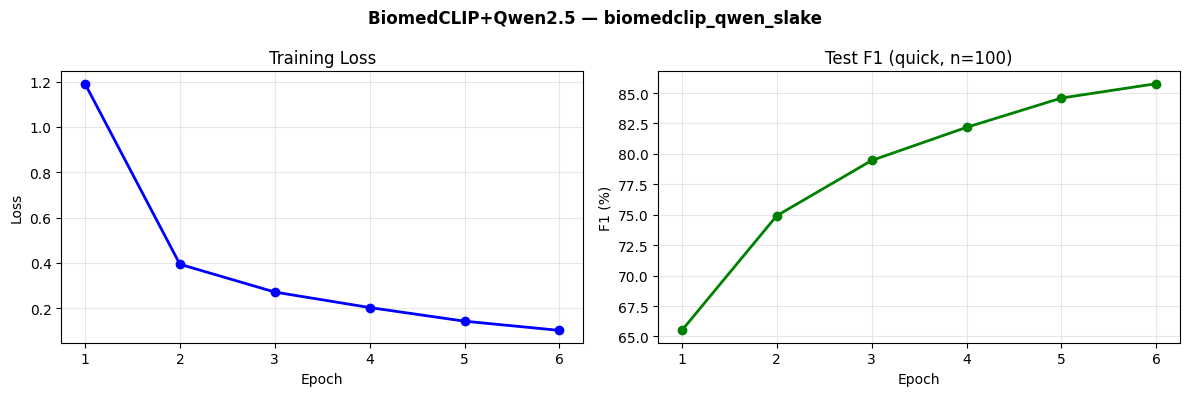

Saved training_curves.png


In [14]:
# Plot training curves
epochs_x = list(range(START_EPOCH + 1, START_EPOCH + NUM_EPOCHS + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_x, train_losses, 'b-o', linewidth=2)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(epochs_x, test_f1s, 'g-o', linewidth=2)
ax2.set(xlabel='Epoch', ylabel='F1 (%)', title='Test F1 (quick, n=100)')
ax2.grid(True, alpha=0.3)
plt.suptitle(f'BiomedCLIP+Qwen2.5 — {EXPERIMENT_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved training_curves.png')

## 🧪 Phần 9: Load & Evaluate / Inference

> Chạy phần này **độc lập** bất cứ lúc nào — không cần chạy lại training

In [15]:
# Load model để evaluate
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

EVAL_FROM = 'best'   # 'best' | 'last' | số epoch

ckpt_path, ckpt_state = ckpt_mgr.load(EVAL_FROM)

eval_tokenizer = AutoTokenizer.from_pretrained(ckpt_path / 'tokenizer')
if eval_tokenizer.pad_token is None:
    eval_tokenizer.pad_token = eval_tokenizer.eos_token

eval_model = BiomedCLIPQwenVQA()
eval_model.vision_encoder = eval_model.vision_encoder.to(DEVICE)
eval_model.projector      = eval_model.projector.to(DEVICE)

eval_model.projector.load_state_dict(
    torch.load(ckpt_path / 'projector.pt', map_location=DEVICE)
)

ve_path = ckpt_path / 'vision_encoder.pt'
if ve_path.exists():
    eval_model.vision_encoder.visual.load_state_dict(
        torch.load(ve_path, map_location=DEVICE)
    )

eval_model.llm.load_adapter(ckpt_path / 'lora_adapter', adapter_name='default')
eval_model.eval()
eval_transform = eval_model.vision_encoder.preprocess

print(f'\n✅ Loaded: {ckpt_path.name}')
print(f'   Best F1 : {ckpt_state.get("best_f1", "?")}')
print(f'   Dataset : {ckpt_state.get("dataset", "?")}')

📂 Loading best: /kaggle/working/checkpoints/biomedclip_qwen_slake/checkpoint_best (epoch=checkpoint_epoch6)
📥 Loading BiomedCLIP vision encoder...
   BiomedCLIP freeze=full: 0/86,191,872 params trainable
📥 Loading LLM: Qwen/Qwen2.5-0.5B-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359

✅ Loaded: checkpoint_best
   Best F1 : 85.77
   Dataset : mdwiratathya/SLAKE-vqa-english


In [16]:
# Inference đơn lẻ
def predict(image_input, question):
    from PIL import Image
    import requests
    from io import BytesIO
    if isinstance(image_input, str):
        if image_input.startswith('http'):
            img = Image.open(BytesIO(requests.get(image_input).content))
        else:
            img = Image.open(image_input)
    else:
        img = image_input
    return generate_answer(eval_model, eval_tokenizer, img, question, eval_transform)


# Test với 5 samples
print('--- Inference samples ---')
for i in range(5):
    s    = raw_ds[TEST_SPLIT][i]
    pred = predict(s['image'], s[Q_COL])
    f1   = token_f1(pred, s[A_COL])
    qtype = 'CLOSED' if str(s[A_COL]).lower() in ['yes','no'] else 'OPEN'
    print(f'[{i}] [{qtype}] Q: {s[Q_COL]}')
    print(f'     GT  : {s[A_COL]}')
    print(f'     Pred: {pred} | F1: {f1:.3f}')
    print()

--- Inference samples ---
[0] [OPEN] Q: What modality is used to take this image?
     GT  : CT
     Pred: CT | F1: 1.000

[1] [OPEN] Q: Which part of the body does this image belong to?
     GT  : Chest
     Pred: Chest | F1: 1.000

[2] [OPEN] Q: What is the main organ in the image?
     GT  : Lung, Spinal Cord
     Pred: Lung | F1: 0.500

[3] [OPEN] Q: What is the largest organ in the picture?
     GT  : Lung
     Pred: Lung | F1: 1.000

[4] [CLOSED] Q: Does the picture contain liver?
     GT  : No
     Pred: No | F1: 1.000



In [17]:
# Full evaluation trên toàn bộ test set
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

print('📥 Loading sentence transformer...')
sim_model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Loaded!')

def cosine_sim_batch(preds, gts):
    pred_emb = sim_model.encode(preds, convert_to_numpy=True)
    gt_emb   = sim_model.encode(gts,   convert_to_numpy=True)
    return [float(cos_sim([p], [g])[0][0]) for p, g in zip(pred_emb, gt_emb)]

smoothie = SmoothingFunction().method1
rouge    = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

eval_model.eval()
preds, gts, qs, q_types = [], [], [], []

for item in tqdm(test_data, desc='Full Eval'):
    q    = str(item[Q_COL])
    gt   = str(item[A_COL])
    pred = predict(item['image'], q)
    preds.append(pred)
    gts.append(gt)
    qs.append(q)
    q_types.append('CLOSED' if gt.lower() in ['yes', 'no'] else 'OPEN')

# Metrics
f1s, accs, bleu1s, bleu4s, rougels = [], [], [], [], []
for pred, gt in zip(preds, gts):
    pred_tok = normalize(pred).split()
    gt_tok   = normalize(gt).split()
    f1s.append(token_f1(pred, gt))
    accs.append(int(normalize(pred) == normalize(gt)))
    bleu1s.append(sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie))
    bleu4s.append(sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie))
    rougels.append(rouge.score(gt, pred)['rougeL'].fmeasure)

print('🔍 Tính Cosine Similarity...')
cosine_scores = cosine_sim_batch(preds, gts)

ci = [i for i, t in enumerate(q_types) if t == 'CLOSED']
oi = [i for i, t in enumerate(q_types) if t == 'OPEN']

def avg(lst, idx=None):
    subset = [lst[i] for i in idx] if idx else lst
    return sum(subset) / max(len(subset), 1) * 100

print('\n' + '='*60)
print('📊 BIOMEDCLIP + QWEN2.5 FULL RESULTS')
print('='*60)
print(f'{"Metric":<22} {"Overall":>10} {"Closed":>10} {"Open":>10}')
print('-'*60)
print(f'{"Exact Match":<22} {avg(accs):>9.2f}% {avg(accs,ci):>9.2f}% {avg(accs,oi):>9.2f}%')
print(f'{"Token F1":<22} {avg(f1s):>9.2f}% {avg(f1s,ci):>9.2f}% {avg(f1s,oi):>9.2f}%')
print(f'{"BLEU-1":<22} {avg(bleu1s):>9.2f}% {avg(bleu1s,ci):>9.2f}% {avg(bleu1s,oi):>9.2f}%')
print(f'{"BLEU-4":<22} {avg(bleu4s):>9.2f}% {avg(bleu4s,ci):>9.2f}% {avg(bleu4s,oi):>9.2f}%')
print(f'{"ROUGE-L":<22} {avg(rougels):>9.2f}% {avg(rougels,ci):>9.2f}% {avg(rougels,oi):>9.2f}%')
print(f'{"Cosine Sim":<22} {avg(cosine_scores):>9.2f}% {avg(cosine_scores,ci):>9.2f}% {avg(cosine_scores,oi):>9.2f}%')
print('='*60)
print(f'  n_total={len(preds)} | n_closed={len(ci)} | n_open={len(oi)}')

# Lưu CSV
df = pd.DataFrame({
    'question'    : qs,
    'prediction'  : preds,
    'ground_truth': gts,
    'q_type'      : q_types,
    'exact_match' : accs,
    'token_f1'    : f1s,
    'bleu1'       : bleu1s,
    'bleu4'       : bleu4s,
    'rouge_l'     : rougels,
    'cosine_sim'  : cosine_scores
})
out_csv = f'{EXPERIMENT_NAME}_predictions.csv'
df.to_csv(out_csv, index=False)
print(f'\n✅ Saved: {out_csv} ({len(df)} rows)')

📥 Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Loaded!


Full Eval:   0%|          | 0/1061 [00:00<?, ?it/s]

🔍 Tính Cosine Similarity...

📊 BIOMEDCLIP + QWEN2.5 FULL RESULTS
Metric                    Overall     Closed       Open
------------------------------------------------------------
Exact Match                82.56%     87.89%     79.89%
Token F1                   85.77%     87.89%     84.70%
BLEU-1                     85.23%     87.89%     83.89%
BLEU-4                     19.52%     15.63%     21.47%
ROUGE-L                    85.61%     87.89%     84.46%
Cosine Sim                 93.61%     96.77%     92.02%
  n_total=1061 | n_closed=355 | n_open=706

✅ Saved: biomedclip_qwen_slake_predictions.csv (1061 rows)


--- 5 mẫu ngẫu nhiên ---
[0] [OPEN] Q: What is the organ on the lower right corner of this image? | GT: Spleen | Pred: Spleen | F1: 1.000
[1] [CLOSED] Q: Does the picture contain kidney? | GT: No | Pred: No | F1: 1.000
[2] [OPEN] Q: Which part of the body does this image belong to? | GT: Chest | Pred: Chest | F1: 1.000
[3] [CLOSED] Q: Does the picture contain brian? | GT: Yes | Pred: Yes | F1: 1.000
[4] [OPEN] Q: Which part of the human body is the organ located in the image? | GT: Pelvic Cavity | Pred: Pelvic Cavity | F1: 1.000


/tmp/ipykernel_23/114288906.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/114288906.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


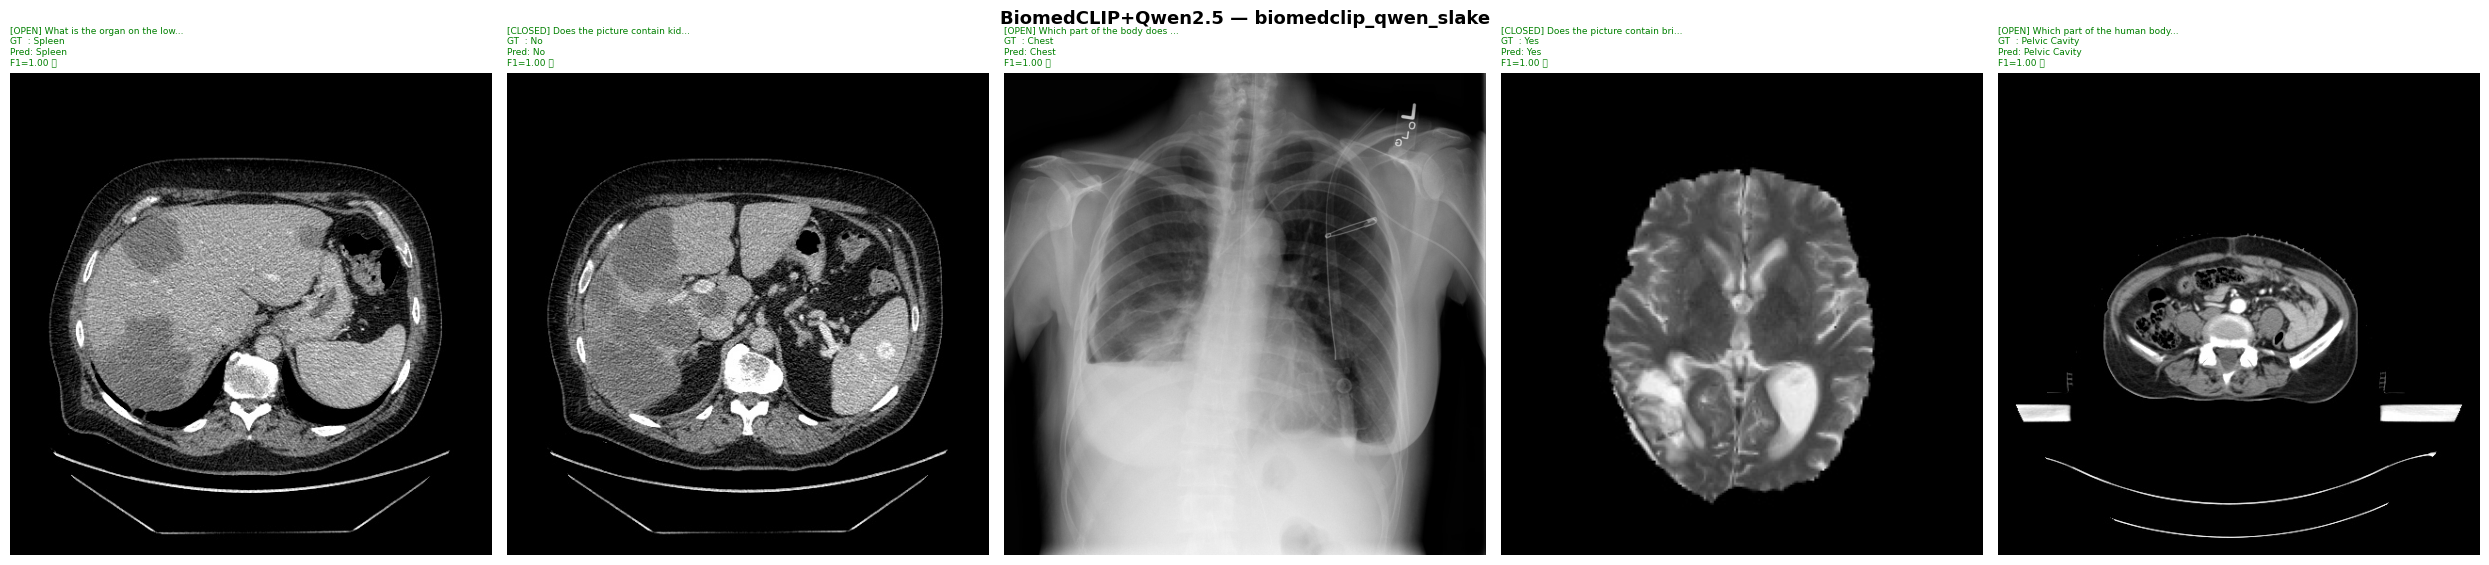


✅ Saved: random_samples.png


In [18]:
# Visualize 5 samples ngẫu nhiên
import random
import matplotlib.pyplot as plt


sample_ids = random.sample(range(len(raw_ds[TEST_SPLIT])), 5)

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
print('--- 5 mẫu ngẫu nhiên ---')

for ax_idx, sid in enumerate(sample_ids):
    item   = raw_ds[TEST_SPLIT][sid]
    q      = str(item[Q_COL])
    gt     = str(item[A_COL])
    pred   = predict(item['image'], q)
    qtype  = 'CLOSED' if gt.lower() in ['yes', 'no'] else 'OPEN'
    em     = normalize(pred) == normalize(gt)
    f1     = token_f1(pred, gt)

    ax = axes[ax_idx]
    ax.imshow(item['image'], cmap='gray')
    ax.axis('off')
    color = 'green' if em else 'red'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

    q_short = q[:28] + '...' if len(q) > 28 else q
    ax.set_title(
        f'[{qtype}] {q_short}\nGT  : {gt}\nPred: {pred}\nF1={f1:.2f} {"✅" if em else "❌"}',
        fontsize=6.5, loc='left', color=color
    )
    print(f'[{ax_idx}] [{qtype}] Q: {q} | GT: {gt} | Pred: {pred} | F1: {f1:.3f}')

plt.suptitle(f'BiomedCLIP+Qwen2.5 — {EXPERIMENT_NAME}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: random_samples.png')